In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [2]:
from pathlib import Path

RAW_DIR = Path("../data/raw")

customers = pd.read_csv(
    RAW_DIR / "Customer.csv",
    encoding="ISO-8859-1"
)

orders = pd.read_csv(
    RAW_DIR / "Orders.csv",
    encoding="ISO-8859-1"
)

order_details = pd.read_csv(
    RAW_DIR / "OrderDetails.csv",
    encoding="ISO-8859-1"
)

products = pd.read_csv(
    RAW_DIR / "Product.csv",
    encoding="ISO-8859-1"
)

In [3]:
df = (
    orders
    .merge(
        customers,
        on="CustomerID",
        how="left"
    )
    .merge(
        order_details,
        on="OrderID",
        how="left"
    )
    .merge(
        products,
        on="ProductID",
        how="left"
    )
)

df.shape

(400, 19)

In [ ]:
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    format="%Y/%m/%d"
)

(400, 19)

In [5]:
df["OrderDate"] = pd.to_datetime(
    df["OrderDate"],
    format="%Y/%m/%d"
)

Analytical Metrics

In [6]:
df["Revenue"] = (
    df["OrderItemQuantity"] *
    df["PerUnitPrice"]
)

df["EstimatedCost"] = (
    df["OrderItemQuantity"] *
    df["ProductStandardCost"]
)

df["GrossProfit"] = (
    df["Revenue"] -
    df["EstimatedCost"]
)

df["PriceRealization"] = (
    df["PerUnitPrice"] /
    df["ProductListPrice"]
)

df["GrossMargin"] = np.where(
    df["Revenue"] != 0,
    df["GrossProfit"] / df["Revenue"],
    np.nan
)

In [7]:
df[
    [
        "OrderID",
        "ProductID",
        "OrderStatus",
        "Revenue",
        "EstimatedCost",
        "GrossProfit",
        "PriceRealization",
        "GrossMargin"
    ]
].head(10)

,OrderID,ProductID,OrderStatus,Revenue,EstimatedCost,GrossProfit,PriceRealization,GrossMargin
0,7272,P001,Shipped,"62,038.68","378,511.32","-316,472.64",0.14,-5.10
1,7273,P002,Shipped,"64,478.76","288,457.48","-223,978.72",0.19,-3.47
2,7274,P003,Canceled,"73,668.08","187,236.56","-113,568.48",0.30,-1.54
3,7275,P004,Pending,"108,798.72","274,483.20","-165,684.48",0.33,-1.52
4,7276,P005,Shipped,"11,658.94","213,283.66","-201,624.72",0.04,-17.29
5,7277,P006,Shipped,"81,339.32","284,919.24","-203,579.92",0.23,-2.50
6,7278,P007,Canceled,"83,818.73","266,901.93","-183,083.20",0.28,-2.18
7,7279,P008,Shipped,"7,588.62","245,688.30","-238,099.68",0.02,-31.38
8,7280,P009,Canceled,"93,396.42","209,843.01","-116,446.59",0.35,-1.25
9,7281,P010,Pending,"9,519.66","65,966.12","-56,446.46",0.13,-5.93


Dataset Shipped

In [8]:
shipped_df = df[
    df["OrderStatus"] == "Shipped"
].copy()

shipped_df.shape

(183, 24)

KPI

In [9]:
kpi = {
    "Orders": shipped_df["OrderID"].nunique(),
    "Customers": shipped_df["CustomerID"].nunique(),
    "Products": shipped_df["ProductID"].nunique(),
    "Units": shipped_df["OrderItemQuantity"].sum(),
    "Revenue": shipped_df["Revenue"].sum(),
    "Gross Profit": shipped_df["GrossProfit"].sum(),
    "Gross Margin": (
        shipped_df["GrossProfit"].sum() /
        shipped_df["Revenue"].sum()
    ),
    "Avg Price Realization": (
        shipped_df["PriceRealization"].mean()
    )
}

kpi

{'Orders': 183,
 'Customers': 183,
 'Products': 183,
 'Units': 16827,
 'Revenue': 14037758.6,
 'Gross Profit': -14580353.36,
 'Gross Margin': -1.0386525210655781,
 'Avg Price Realization': 1.7697242187292774}

Order Status Analysis

In [10]:
status_analysis = (
    df.groupby("OrderStatus")
      .agg(
          Orders=("OrderID", "nunique"),
          Units=("OrderItemQuantity", "sum"),
          Revenue=("Revenue", "sum")
      )
      .reset_index()
)

status_analysis

,OrderStatus,Orders,Units,Revenue
0,Canceled,111,9456,"8,390,685.96"
1,Pending,106,9413,"8,091,646.15"
2,Shipped,183,16827,"14,037,758.60"


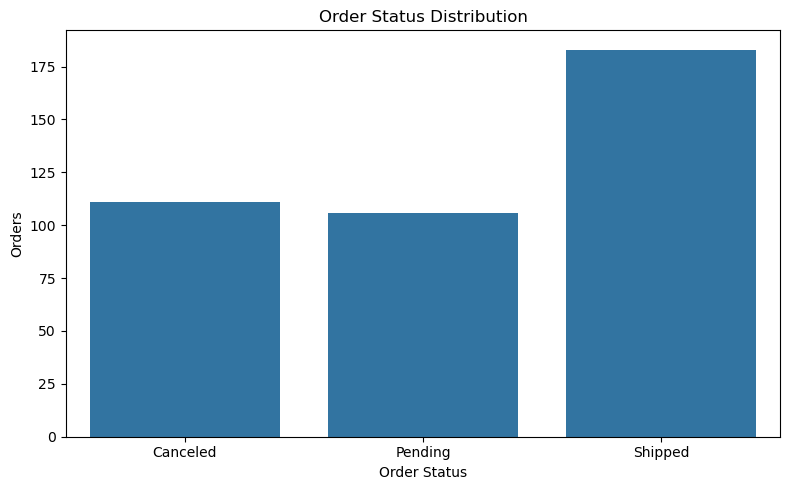

In [11]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=status_analysis,
    x="OrderStatus",
    y="Orders"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Orders")
plt.tight_layout()
plt.show()

Category Profitability

In [12]:
category_analysis = (
    shipped_df.groupby("CategoryName")
    .agg(
        Units=("OrderItemQuantity", "sum"),
        Revenue=("Revenue", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        PriceRealization=("PriceRealization", "mean")
    )
    .reset_index()
)

category_analysis["GrossMargin"] = (
    category_analysis["GrossProfit"] /
    category_analysis["Revenue"]
)

category_analysis.sort_values(
    "Revenue",
    ascending=False
)

,CategoryName,Units,Revenue,GrossProfit,PriceRealization,GrossMargin
3,Storage,4943,"4,469,545.94","-10,406,159.63",3.37,-2.33
0,CPU,4851,"3,172,472.93","-2,983,843.40",0.58,-0.94
4,Video Card,2964,"2,861,513.42","-336,723.44",0.92,-0.12
1,Mother Board,2880,"2,088,755.77","1,218,689.57",2.16,0.58
2,RAM,1189,"1,445,470.54","-2,072,316.46",0.84,-1.43


Product profitability

In [13]:
product_analysis = (
    shipped_df.groupby(
        [
            "ProductID",
            "ProductName",
            "CategoryName"
        ]
    )
    .agg(
        Units=("OrderItemQuantity", "sum"),
        Revenue=("Revenue", "sum"),
        GrossProfit=("GrossProfit", "sum"),
        PriceRealization=("PriceRealization", "mean")
    )
    .reset_index()
)

product_analysis["GrossMargin"] = (
    product_analysis["GrossProfit"] /
    product_analysis["Revenue"]
)

In [14]:
bottom_products = (
    product_analysis
    .sort_values("GrossMargin")
    .head(10)
)

bottom_products

,ProductID,ProductName,CategoryName,Units,Revenue,GrossProfit,PriceRealization,GrossMargin
140,P299,Corsair Vengeance LPX (CMK16GX4M2B3000C15B) 16GB,RAM,45,"1,889.55","-594,360.45",0.00,-314.55
123,P261,SanDisk SDSSDA-120G-G26,Storage,49,"2,841.02","-346,218.32",0.01,-121.86
154,P336,Intel Xeon E5-2699 V4 (OEM/Tray),CPU,43,730.57,"-65,301.09",0.01,-89.38
126,P264,Samsung MZ-V6P1T0BW,Storage,104,"9,254.96","-731,605.68",0.01,-79.05
121,P253,Western Digital WD2003FZEX,Storage,95,"8,549.05","-668,198.65",0.01,-78.16
163,P357,SanDisk SDSSDHII-240G-G25,Storage,81,"8,909.19","-568,107.27",0.02,-63.77
4,P008,Intel Xeon E5-2695 V4,CPU,138,"7,588.62","-238,099.68",0.02,-31.38
13,P023,Intel Xeon E5-1680 V3 (OEM/Tray),CPU,148,"7,086.24","-217,851.56",0.03,-30.74
85,P164,G.Skill Ripjaws V Series,Storage,75,"1,274.25","-37,559.25",0.02,-29.48
177,P389,AMD 100-5056062,Video Card,99,"5,740.02","-127,300.14",0.04,-22.18


Prize Realization

In [15]:
price_analysis = (
    shipped_df.groupby("CategoryName")
    .agg(
        AvgPriceRealization=("PriceRealization", "mean"),
        Revenue=("Revenue", "sum"),
        GrossProfit=("GrossProfit", "sum")
    )
    .reset_index()
)

price_analysis

,CategoryName,AvgPriceRealization,Revenue,GrossProfit
0,CPU,0.58,"3,172,472.93","-2,983,843.40"
1,Mother Board,2.16,"2,088,755.77","1,218,689.57"
2,RAM,0.84,"1,445,470.54","-2,072,316.46"
3,Storage,3.37,"4,469,545.94","-10,406,159.63"
4,Video Card,0.92,"2,861,513.42","-336,723.44"


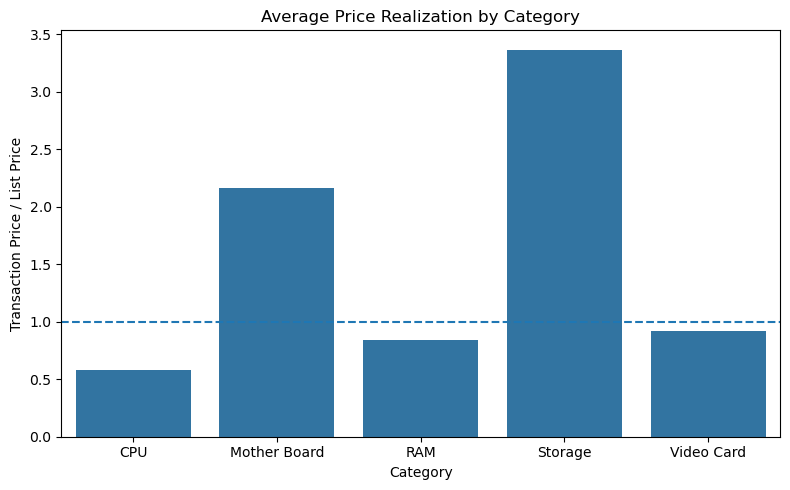

In [16]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=price_analysis,
    x="CategoryName",
    y="AvgPriceRealization"
)

plt.axhline(
    1,
    linestyle="--"
)

plt.title("Average Price Realization by Category")
plt.xlabel("Category")
plt.ylabel("Transaction Price / List Price")

plt.tight_layout()
plt.show()

Export

In [17]:
processed_dir = Path("../data/processed")
processed_dir.mkdir(exist_ok=True)

shipped_df.to_csv(
    processed_dir / "shipped_order_analytics.csv",
    index=False,
    encoding="utf-8-sig"
)

df.to_csv(
    processed_dir / "order_analytics.csv",
    index=False,
    encoding="utf-8-sig"
)